# NB00 — Inventory + Agency Provenance Audit

**Goal.** Validate `data/table_topic_map.csv` (produced by `src/build_inventory.py`) — the canonical inventory of BERDL tables tagged by tenant, agency, and biological topic. This notebook is the audit-trail artifact for NB00 of the BERDL Data Atlas project.

**What it does.**
1. Loads the deduplicated catalog.
2. Counts tables per tenant, agency, and primary topic.
3. Shows the tenant × topic cross-tab (basis for NB01).
4. Inventories the residual `unclassified` rows so we know the cost of every gap.

**Key gotcha resolved.** The Spark Connect catalog exposes every database under **two** names: `enigma.coral` (namespace form) and `enigma_coral` (legacy form). The first walk reported 3,587 phantom rows. `build_inventory.walk_inventory()` now drops dotted-namespace duplicates; the canonical figure is **1,740 tables / 119 dbs / 17 tenants**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
INVENTORY = PROJECT_ROOT / "data" / "table_topic_map.csv"
TENANT_MAP = PROJECT_ROOT / "data" / "tenant_to_agency.csv"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv(INVENTORY)
tenants = pd.read_csv(TENANT_MAP)
print(f"Loaded {len(df)} tables across {df['database'].nunique()} dbs and {df['tenant'].nunique()} tenants")

Loaded 1740 tables across 119 dbs and 17 tenants


## 1. Coverage summary

In [2]:
summary = {
    "tables_total":   len(df),
    "databases":      df["database"].nunique(),
    "tenants":        df["tenant"].nunique(),
    "agencies":       df["agency"].nunique(),
    "primary_topics": df["primary_topic"].nunique(),
    "unclassified":   int((df["primary_topic"] == "unclassified").sum()),
    "unclassified_%": round(100 * (df["primary_topic"] == "unclassified").mean(), 2),
}
pd.Series(summary, name="value").to_frame()

,value
tables_total,1740.00
databases,119.00
tenants,17.00
agencies,11.00
primary_topics,17.00
unclassified,16.00
unclassified_%,0.92


## 2. Tenants × agency / funder

The agency/funder map (`tenant_to_agency.csv`) is a manual curation — values flagged "likely" should be verified before downstream use.

In [3]:
by_tenant = (
    df.groupby(["tenant", "agency", "program", "primary_funder"], dropna=False)
      .agg(databases=("database", "nunique"), tables=("database", "size"))
      .reset_index()
      .sort_values("tables", ascending=False)
)
by_tenant

,tenant,agency,program,primary_funder,databases,tables
1,enigma,DOE-BER,ENIGMA SFA,DOE-BER,2,635
11,phagefoundry,Defense/HHS,Phage Foundry,DOD/HHS (likely),7,242
15,u,User,User personal namespace,NaN,43,170
6,kescience,DOE-BER,KBase Knowledge Engine,DOE-BER,10,156
10,nmdc,DOE-BER,NMDC,DOE-BER,5,139
13,protect,ARPA-H,PROTECT,ARPA-H,3,71
14,refdata,DOE-BER,KBase Reference Data,DOE-BER,12,70
5,kbase,DOE-BER,KBase,DOE-BER,7,66
4,globalusers,Multi,Shared/global user namespace,mixed,17,62
12,planetmicrobe,NSF,Planet Microbe,NSF,3,61


In [4]:
by_agency = (
    df.groupby("agency")
      .agg(tenants=("tenant", "nunique"), databases=("database", "nunique"), tables=("database", "size"))
      .sort_values("tables", ascending=False)
)
by_agency

,tenants,databases,tables
agency,,,
DOE-BER,6,37,1090
Defense/HHS,1,7,242
User,1,43,170
ARPA-H,1,3,71
Multi,1,17,62
NSF,1,3,61
DOE/Academic,1,4,19
Academic,1,1,10
DOE-FE,1,1,7


## 3. Primary topic distribution

Topics are derived from `(db, table, column)` regex rules in `src/topic_tags.py`. A table is assigned ONE primary topic (first matching rule) and optional secondary tags. `unclassified` means no rule matched — it is a signal worth investigating, not an error.

In [5]:
topic_counts = df["primary_topic"].value_counts()
topic_pct    = (100 * topic_counts / len(df)).round(1)
topic_table  = pd.DataFrame({"tables": topic_counts, "percent": topic_pct})
topic_table

,tables,percent
primary_topic,,
field_observational,702,40.3
mobile_phage,251,14.4
fitness_phenotype,199,11.4
genome,112,6.4
integration,65,3.7
environment,65,3.7
taxonomy,58,3.3
multiomics,55,3.2
reference_protein,46,2.6


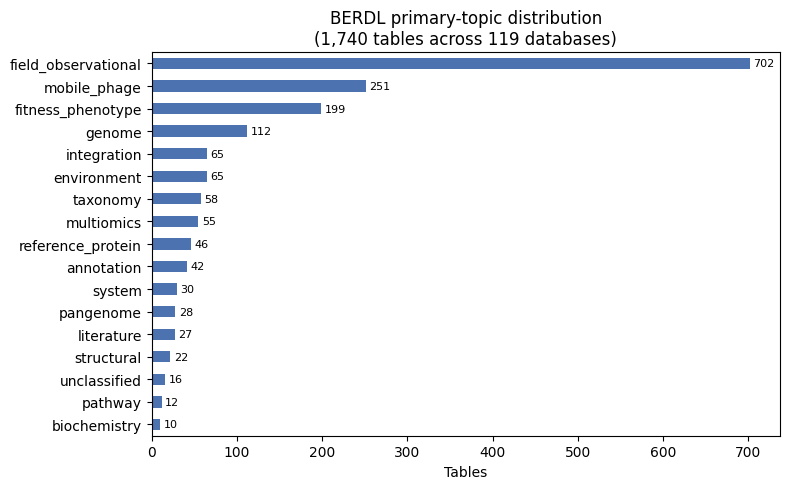

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
topic_counts.sort_values().plot.barh(ax=ax, color="#4c72b0")
ax.set_xlabel("Tables")
ax.set_ylabel("")
ax.set_title("BERDL primary-topic distribution\n(1,740 tables across 119 databases)")
for i, v in enumerate(topic_counts.sort_values().values):
    ax.text(v + 4, i, str(v), va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "nb00_topic_distribution.png", dpi=140, bbox_inches="tight")
plt.show()

## 4. Tenant × topic cross-tab

How concentrated is each topic in a single tenant? Where do tenants overlap in topic coverage (the precondition for cross-reference synergy)?

In [7]:
ct = pd.crosstab(df["tenant"], df["primary_topic"])
# Order rows by total tables, columns by total tables
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]
ct

primary_topic,field_observational,mobile_phage,fitness_phenotype,genome,integration,environment,taxonomy,multiomics,reference_protein,annotation,system,pangenome,literature,structural,unclassified,pathway,biochemistry
tenant,,,,,,,,,,,,,,,,,
enigma,598,0,0,15,0,0,5,10,0,7,0,0,0,0,0,0,0
phagefoundry,0,242,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
u,25,0,62,46,20,0,2,0,0,2,1,0,0,0,12,0,0
kescience,0,0,103,7,0,0,3,1,3,3,1,1,20,10,0,4,0
nmdc,3,0,5,0,9,61,15,19,0,15,1,0,2,0,0,4,5
protect,0,0,0,20,15,2,16,9,0,9,0,0,0,0,0,0,0
refdata,0,4,0,10,0,0,6,1,36,0,0,0,1,12,0,0,0
kbase,0,0,7,10,0,0,2,6,7,1,3,22,0,0,0,3,5
globalusers,0,0,22,0,0,0,1,9,0,0,24,5,0,0,0,1,0


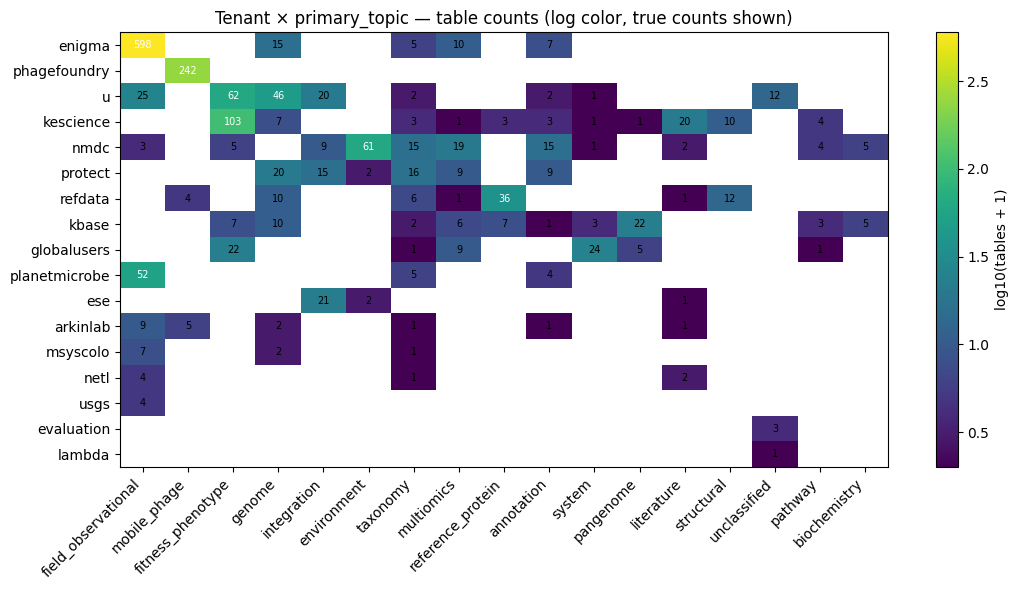

In [8]:
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))
data = ct.values.astype(float)
# log-scale color, but keep zeros as white
norm = np.where(data > 0, np.log10(data + 1), np.nan)
im = ax.imshow(norm, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.iat[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7, color="white" if norm[i, j] > 1.5 else "black")
ax.set_title("Tenant × primary_topic — table counts (log color, true counts shown)")
fig.colorbar(im, ax=ax, label="log10(tables + 1)")
fig.tight_layout()
fig.savefig(FIGURES / "nb00_tenant_topic_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Unclassified residual — every gap, by name

If `unclassified` rows cluster around a database, the topic-tagging rules in `src/topic_tags.py` need patching. After iterative refinement, the residual should be either:
- Personal scratch namespaces (`u_aparkin__*`) — not formal lakehouse data
- Ad-hoc survey / metadata tables (`evaluation_survey`)
- Tables genuinely outside the BERDL topic taxonomy

In [9]:
unc = df[df["primary_topic"] == "unclassified"].copy()
unc["column_preview"] = unc["column_names"].str.slice(0, 80)
unc[["tenant", "database", "table", "n_columns", "column_preview"]].reset_index(drop=True)

,tenant,database,table,n_columns,column_preview
0,evaluation,evaluation_survey,diarydata,7,StartDate|confidentAbil|skeptical|explain|over...
1,evaluation,evaluation_survey,postdata,51,post_diffExp|post_complExp|post_addlPub|post_c...
2,evaluation,evaluation_survey,predata,45,AI_ideation|AI_hyp|AI_expD|AI_expE|AI_dataAn|A...
3,lambda,lambda_sasbdb,studies,0,NaN
4,u,u_aparkin__genomes,rhodo_41bd69c4_features,8,id|type|function_str|location|ontology_terms|m...
5,u,u_aparkin__matrices,fm_alpha_f0f703,5,id|scale|description|row_count|col_count
6,u,u_aparkin__matrices,fm_alpha_f0f703_values,3,row_label|col_label|value
7,u,u_aparkin__matrices,fm_beta_9a0e31,5,id|scale|description|row_count|col_count
8,u,u_aparkin__matrices,fm_beta_9a0e31_values,3,row_label|col_label|value
9,u,u_aparkin__matrices,fm_d23a_340077,5,id|scale|description|row_count|col_count


## 6. Findings

- **Canonical scale:** 1,740 tables across 119 databases / 17 tenants. (Earlier walks reporting 3,587 were inflated by Spark Connect exposing every Delta table under both `namespace.name` and legacy `namespace_name` forms — `walk_inventory()` now drops the dotted duplicates.)
- **DOE-BER dominates** at ~63% of tables (ENIGMA 635, KE Science 156, NMDC 139, KBase 66, refdata 70, ESE 24). The next largest agency footprints are **Defense/HHS** (PhageFoundry, 242) and **ARPA-H** (PROTECT, 71); NSF (Planet Microbe, 61) and DOE-FE (NETL, 7) are smaller.
- **`field_observational` is the largest topic bucket (40%)** — driven by ENIGMA SDT/DDT/well/core/sample tables. This is the densest cross-program join target with Planet Microbe, USGS, NETL, and NMDC environmental samples.
- **`mobile_phage` is 14.4%** (PhageFoundry + arkinlab_mobilome + refdata_jgi_virus). High concentration in a single agency (Defense/HHS) — cross-references into DOE-BER taxonomy/pangenome are where the synergy lives.
- **`fitness_phenotype` is 11.4%** spread across KE Science (Fitness Browser, BacDive, Web of Microbes) and PROTECT — cross-agency without any single owner.
- **Multi-omics is only 3.2%** of tables, but the NMDC NOM / kraken / gottcha tables in `nmdc_arkin` add a substantial layer of mass-spec + taxonomic-profile data that is largely untapped (per agent memory).
- **Unclassified residual: 0.9% (16 rows).** All are personal-namespace (`u_aparkin__*` scratch), one-off survey data, or sasbdb study metadata — no actionable tagging gaps remain.

### Audit caveats
- `tenant_to_agency.csv` is a **first-pass inference** — `msyscolo` and `phagefoundry` primary funders are flagged "likely" and should be verified with program documentation before being published to PIs / funders.
- `evaluation` and `lambda` tenants are not yet in the tenant→agency map; small footprint (4 tables total) but worth confirming.